### <b> PROJECT TITLE: </b>
`Aviation disruption Around the war zone during Iran US war - 2026`

### <b> INTRODUCTION: </b>
The global civil aviation sector experienced significant disruptions in February due to the conflict between the United States and Iran. These disruptions affected `airline operations, airport activities, and international air routes` across many countries. The dataset used in this project contains `multiple tables` that document the impacts of this event, including financial losses in the aviation sector, airport disruptions in 35 countries, airspace closures in 25 countries, and flight cancellations and rerouting in more than 40 countries.

This dataset provides opportunities for both predictive modeling and data analysis. `Several outcomes can be predicted`, such as estimated financial losses, flight cancellations, delay durations, airspace closure severity, and the number of passengers impacted. In this project, machine learning techniques will be used to predict estimated financial loss, flight cancellations, passenger impact, and overall aviation disruption patterns. The goal is to better understand the extent of global aviation disruptions and `identify key factors influencing these impacts`.

### <b> PROBLEM STATEMENT:</b>
This project analyzes how a geopolitical conflict can affect international airspace, airport and airline operations, and cause economic losses far beyond the actual battleground. Such disruptions create operational challenges for aviation authorities and airline companies, making it difficult to anticipate and effectively manage their impacts. The results will help identify the key factors that contribute to aviation disruptions and provide insights that support improved decision‑making and preparedness for future aviation crises.

### <b> OBJECTIVES: </b>
* `Collect and pre-processing` aviation disruption datasets. <br>
* Conduct`EDA` for airloss and passenger affected. <br>
* `Predict` estimated losses across multiple countries. <br>
* Predict flight cancellation due to airport closures. <br>
* `Building model` to classify the severity of the aviation disruption in different regions. <br>
* `Visualize` prediction and disruption patterns on `maps` to provide clear geographical insights. <br>

### <b> METHODOLOGY: </b>

#### <b> Data preprocessing: </b>
<b> Note: </b> A `Data Overview` can be find at the end of the documentation.

* `Merging` multi-table dataset
* Handling `date and time` and encoding categorical variables
* Feature engineering(no.of.flights,airspace closure etc.)

####  <b> Model development: </b>

* `Regression models` for estimated loss and passenger impacted <br>
* `classification models` for flight cancellations and disruption severity <br>
* Model evaluations will use metrics such as `RMSE, R square,accuracy`.<br>

#### <b> Visualization: </b>

* Bubble maps using matplotlib/plotly to show flight cancellation, estimation loss <br>
* `HeatMaps` using seaborn to visualize disruption severity

####  <b> Analysis: </b>
* Identifying key factors influencing aviation disruption
* Providing insights for decision making

### <b> TOOLS AND TECHNOLOGIES: </b>

`Programming Language:` Python <br>
`Libraries:` Matplotlib, Numpy,Pandas, Seaborn, scikit-learn <br>
`visualization :` Bubble map, heat map <br>   




### <b> DATA OVERVIEW AND DATA CLEANING</b>

In [34]:
# Importing libraries required for the project
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

#for KPI panel
from matplotlib.patches import FancyBboxPatch

In [35]:
# loading data from the file
folder_name = "Aviation_disruption/"

#reading csv files using pandas

airloss_estimation = pd.read_csv(folder_name + "airline_losses_estimate.csv")
airport_disruption = pd.read_csv(folder_name + "airport_disruptions.csv")
airspace_closures = pd.read_csv(folder_name + "airspace_closures.csv")
flight_cancellation = pd.read_csv(folder_name + "flight_cancellations.csv")
flight_rerouted = pd.read_csv(folder_name+ "flight_reroutes.csv")

# Remove Iran from each relevant dataset before analysis
if "country" in airloss_estimation.columns:
    airloss_estimation = airloss_estimation[airloss_estimation["country"] != "Iran"]
if "country" in airport_disruption.columns:
    airport_disruption = airport_disruption[airport_disruption["country"] != "Iran"]
if "country" in airspace_closures.columns:
    airspace_closures = airspace_closures[airspace_closures["country"] != "Iran"]


datasets ={
    'Airloss Estimation' : airloss_estimation,
    'Airport Disruption' : airport_disruption, 
    'Airspace closures' : airspace_closures,
    'Flight cancellations' : flight_cancellation,
    'Flight rerouted': flight_rerouted

}

for key,table in datasets.items():
    print("="*200)
    print(f'📊{key} data')
    print("="*200)
    print(f'\nshape : {table.shape[0]} rows ,{table.shape[1]} columns')
    print(f'\nColumns: {list(table.columns)}')
    print(f'\nDatatypes:\n{table.dtypes}')

    #cleaning
    table = table.reset_index(drop=True)

    #checking missing data
    missingVal = table.isna().sum()
    if missingVal.sum() > 0 :
        print(f'\n✅ Has missing values')
    else:
        print(f'\n🚫 No missing values')

    # Displaying first five values from all the tables    
    print(f'\nFirst 5 rows: \n')
    display(table.head())



📊Airloss Estimation data

shape : 35 rows ,7 columns

Columns: ['airline', 'country', 'estimated_daily_loss_usd', 'cancelled_flights', 'rerouted_flights', 'additional_fuel_cost_usd', 'passengers_impacted']

Datatypes:
airline                     object
country                     object
estimated_daily_loss_usd     int64
cancelled_flights            int64
rerouted_flights             int64
additional_fuel_cost_usd     int64
passengers_impacted          int64
dtype: object

🚫 No missing values

First 5 rows: 



,airline,country,estimated_daily_loss_usd,cancelled_flights,rerouted_flights,additional_fuel_cost_usd,passengers_impacted
0,Emirates,UAE,4200000,18,62,2835200,9180
1,Qatar Airways,Qatar,3100000,12,41,1765800,6540
2,Etihad Airways,UAE,1800000,8,29,1023400,4320
3,Turkish Airlines,Turkey,2400000,14,38,1432600,7700
4,British Airways,UK,1950000,6,32,1185600,4680


📊Airport Disruption data

shape : 31 rows ,10 columns

Columns: ['airport', 'iata', 'icao', 'country', 'latitude', 'longitude', 'flights_cancelled', 'flights_delayed', 'flights_diverted', 'runway_status']

Datatypes:
airport               object
iata                  object
icao                  object
country               object
latitude             float64
longitude            float64
flights_cancelled      int64
flights_delayed        int64
flights_diverted       int64
runway_status         object
dtype: object

🚫 No missing values

First 5 rows: 



,airport,iata,icao,country,latitude,longitude,flights_cancelled,flights_delayed,flights_diverted,runway_status
0,Dubai International,DXB,OMDB,UAE,25.2532,55.3657,87,112,24,FULLY OPERATIONAL
1,Hamad International,DOH,OTHH,Qatar,25.2736,51.6080,62,78,18,FULLY OPERATIONAL
2,Ben Gurion International,TLV,LLBG,Israel,32.0114,34.8866,128,41,0,RESTRICTED - Security Alert
3,Istanbul Airport,IST,LTFM,Turkey,41.2753,28.7519,44,67,12,FULLY OPERATIONAL
4,Muscat International,MCT,OOMS,Oman,23.5933,58.2844,38,54,10,FULLY OPERATIONAL


📊Airspace closures data

shape : 23 rows ,7 columns

Columns: ['country', 'region', 'closure_start_time', 'closure_end_time', 'closure_reason', 'authority', 'NOTAM_reference']

Datatypes:
country               object
region                object
closure_start_time    object
closure_end_time      object
closure_reason        object
authority             object
NOTAM_reference       object
dtype: object

🚫 No missing values

First 5 rows: 



,country,region,closure_start_time,closure_end_time,closure_reason,authority,NOTAM_reference
0,Iraq,Baghdad FIR,2026-03-01T00:30:00Z,2026-03-05T12:00:00Z,Proximity to conflict zone - EASA Level 2 advi...,GCAA Iraq,A0330/26
1,Saudi Arabia,Jeddah FIR,2026-03-01T02:00:00Z,2026-03-02T18:00:00Z,Precautionary airspace restriction - missile t...,GACA,A0712/26
2,UAE,Emirates FIR,2026-03-01T03:00:00Z,2026-03-01T18:00:00Z,Temporary SIGMET - unknown airborne objects,GCAA UAE,A0891/26
3,Kuwait,Kuwait FIR,2026-03-01T00:00:00Z,2026-03-03T06:00:00Z,Conflict proximity advisory - restricted below...,CAAK,A0101/26
4,Bahrain,Bahrain FIR,2026-03-01T01:00:00Z,2026-03-02T23:59:00Z,Military NOTAM - airspace reserved for coaliti...,Civil Aviation Affairs BH,A0200/26


📊Flight cancellations data

shape : 50 rows ,9 columns

Columns: ['date', 'airport', 'country', 'airline', 'flight_number', 'origin', 'destination', 'cancellation_reason', 'aircraft_type']

Datatypes:
date                   object
airport                object
country                object
airline                object
flight_number          object
origin                 object
destination            object
cancellation_reason    object
aircraft_type          object
dtype: object

🚫 No missing values

First 5 rows: 



,date,airport,country,airline,flight_number,origin,destination,cancellation_reason,aircraft_type
0,2026-02-28,Dubai International (DXB),UAE,Emirates,EK0912,DXB,IKA,Airspace closed - Iranian FIR shutdown,Boeing 777-300ER
1,2026-02-28,Tehran Imam Khomeini (IKA),Iran,Iran Air,IR0702,IKA,DXB,Airspace closed - CAOI emergency NOTAM,Airbus A320-200
2,2026-02-28,Ben Gurion International (TLV),Israel,El Al,LY0082,TLV,JFK,Full airspace closure - IAA emergency,Boeing 787-9
3,2026-02-28,Ben Gurion International (TLV),Israel,Wizz Air,W60001,TLV,LTN,Full airspace closure - IAA emergency,Airbus A321-200
4,2026-03-01,Hamad International (DOH),Qatar,Qatar Airways,QR0502,DOH,IKA,Destination airspace closed,Airbus A350-900


📊Flight rerouted data

shape : 45 rows ,7 columns

Columns: ['flight_id', 'airline', 'original_route', 'diverted_route', 'additional_distance_km', 'additional_fuel_cost_usd', 'delay_minutes']

Datatypes:
flight_id                   object
airline                     object
original_route              object
diverted_route              object
additional_distance_km       int64
additional_fuel_cost_usd     int64
delay_minutes                int64
dtype: object

🚫 No missing values

First 5 rows: 



,flight_id,airline,original_route,diverted_route,additional_distance_km,additional_fuel_cost_usd,delay_minutes
0,EK0201-20260301,Emirates,LHR-DXB via standard Gulf,LHR-DXB via Southern Red Sea,620,48400,55
1,EK0203-20260301,Emirates,LHR-DXB via standard Gulf,LHR-DXB via Southern Red Sea,620,48400,52
2,BA0105-20260301,British Airways,LHR-SIN via Muscat/Gulf,LHR-SIN via Cairo/Colombo,980,76440,88
3,BA0107-20260302,British Airways,LHR-SIN via Muscat/Gulf,LHR-SIN via Cairo/Colombo,980,76440,91
4,LH0760-20260301,Lufthansa,FRA-BOM via Gulf,FRA-BOM via Egypt/Red Sea,870,67860,77


In [36]:
#### Summary statistics for each dataset

for key,table in datasets.items():
    print("="*200)
    print(f'📊{key} data')
    print("="*200)
    display(table.describe())
print("="*200)    


📊Airloss Estimation data


,estimated_daily_loss_usd,cancelled_flights,rerouted_flights,additional_fuel_cost_usd,passengers_impacted
count,3.500000e+01,35.000000,35.000000,3.500000e+01,35.000000
mean,1.395429e+06,5.571429,21.542857,7.887429e+05,3416.285714
std,8.218499e+05,3.632255,11.892516,5.160285e+05,1790.535716
min,3.800000e+05,2.000000,0.000000,0.000000e+00,1020.000000
25%,6.950000e+05,3.000000,12.000000,4.180000e+05,2260.000000
50%,1.340000e+06,5.000000,22.000000,7.680000e+05,3360.000000
75%,1.665000e+06,6.000000,27.500000,9.660000e+05,4010.000000
max,4.200000e+06,18.000000,62.000000,2.835200e+06,9180.000000


📊Airport Disruption data


,latitude,longitude,flights_cancelled,flights_delayed,flights_diverted
count,31.000000,31.000000,31.000000,31.000000,31.000000
mean,33.125958,48.002490,31.483871,39.645161,7.903226
std,12.646459,39.839858,24.911672,21.918863,5.153347
min,1.364400,-70.015200,3.000000,5.000000,0.000000
25%,25.105500,34.255750,16.000000,24.000000,4.500000
50%,31.521600,46.698800,22.000000,35.000000,6.000000
75%,40.871400,56.900800,39.500000,51.000000,10.000000
max,55.972600,140.392900,128.000000,112.000000,24.000000


📊Airspace closures data


,country,region,closure_start_time,closure_end_time,closure_reason,authority,NOTAM_reference
count,23,23,23,23,23,23,23
unique,23,23,17,19,23,23,22
top,Iraq,Baghdad FIR,2026-03-01T08:00:00Z,2026-03-02T20:00:00Z,Proximity to conflict zone - EASA Level 2 advi...,GCAA Iraq,A0330/26
freq,1,1,3,2,1,1,2


📊Flight cancellations data


,date,airport,country,airline,flight_number,origin,destination,cancellation_reason,aircraft_type
count,50,50,50,50,50,50,50,50,50
unique,8,21,18,21,50,20,12,31,16
top,2026-03-01,Dubai International (DXB),UAE,Emirates,EK0912,DXB,IKA,Airspace closure - Iranian FIR,Boeing 777-300ER
freq,19,10,10,6,1,10,22,4,9


📊Flight rerouted data


,additional_distance_km,additional_fuel_cost_usd,delay_minutes
count,45.000000,45.000000,45.000000
mean,738.888889,57635.111111,65.466667
std,294.149175,22942.902311,26.306411
min,280.000000,21840.000000,23.000000
25%,520.000000,40560.000000,46.000000
50%,730.000000,56940.000000,65.000000
75%,980.000000,76440.000000,85.000000
max,1350.000000,105300.000000,122.000000


#### Visualization of the Datasets

#### ESTIMATED LOSS


C:\Users\ramya\AppData\Local\Temp\ipykernel_57368\945395146.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:0f}'.format(x/1e6) for x in plt.gca().get_yticks()])


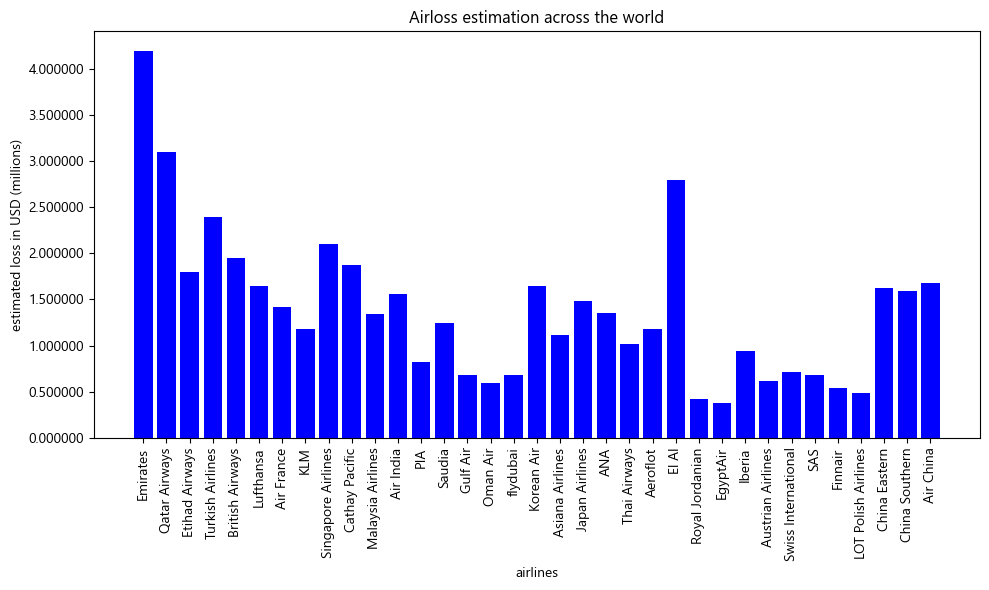

In [37]:
# visualizing each dataset

# Airloss estimation graph
plt.figure(figsize = (10,6))

plt.bar(airloss_estimation["airline"], airloss_estimation["estimated_daily_loss_usd"],color = "blue")

plt.xlabel("airlines")
plt.ylabel("estimated loss in USD (millions)")
plt.xticks(rotation = 90)
plt.title("Airloss estimation across the world")

#Formatting to show values in millions
plt.gca().set_yticklabels(['{:0f}'.format(x/1e6) for x in plt.gca().get_yticks()])

plt.tight_layout()
plt.show()

#### AIRPORT DISRUPTION


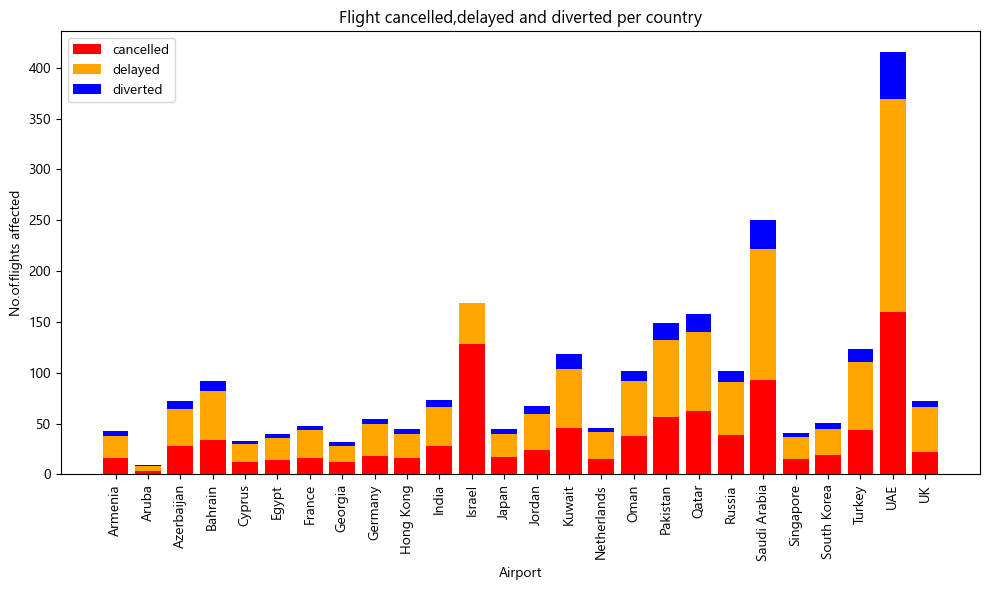

In [38]:
#Airport_disruption Visualization

plt.figure(figsize =(10,6))

airline_grouped = airport_disruption.groupby("country").sum().reset_index()


airport = airline_grouped["country"]
cancelled_flights = airline_grouped["flights_cancelled"]
delayed_flights = airline_grouped["flights_delayed"]
diverted_flights = airline_grouped["flights_diverted"]


plt.bar(airport,cancelled_flights, label ="cancelled",color = "red")
plt.bar(airport, delayed_flights, bottom = cancelled_flights,label ="delayed", color = "orange")
plt.bar(airport, diverted_flights,bottom = (cancelled_flights + delayed_flights),label ="diverted", color = "blue")

plt.xticks(rotation =90)
plt.xlabel("Airport")
plt.ylabel("No.of.flights affected")
plt.title("Flight cancelled,delayed and diverted per country")

plt.legend()
plt.tight_layout()
plt.show()

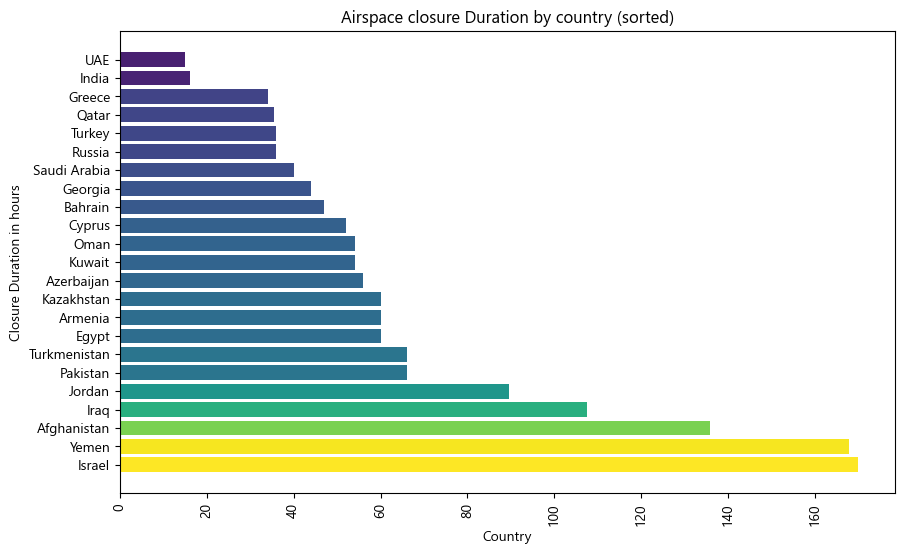

In [39]:
#Air closures visualization

plt.figure(figsize = (10,6))

country = airspace_closures["country"]

#using pandas datetime
start_time = pd.to_datetime(airspace_closures["closure_start_time"])
end_time = pd.to_datetime(airspace_closures["closure_end_time"])
airspace_closures["closure_duration_hours"] = (end_time - start_time).dt.total_seconds() / 3600

sorted_closures = airspace_closures.sort_values("closure_duration_hours", ascending= False)

plt.barh(sorted_closures["country"],sorted_closures["closure_duration_hours"], color = plt.cm.viridis(sorted_closures["closure_duration_hours"]/sorted_closures["closure_duration_hours"].max()))
plt.xticks(rotation = 90)
plt.xlabel("Country")
plt.ylabel("Closure Duration in hours")
plt.title("Airspace closure Duration by country (sorted)")
plt.show()


#### FLIGHT CANCELLATION

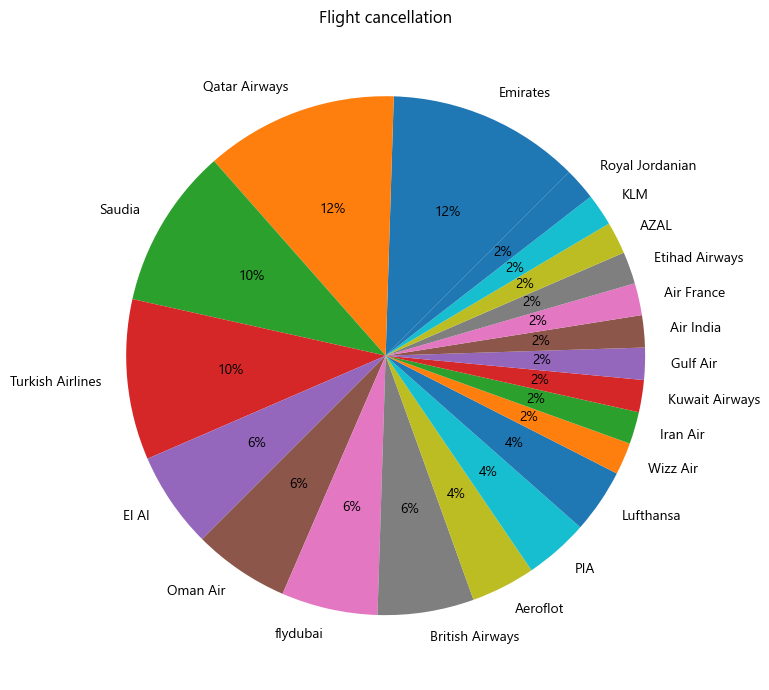

In [40]:
# flight cancellation visualization
plt.figure(figsize = (10,7))

airline = flight_cancellation["airline"]
count = flight_cancellation["airline"].value_counts()

plt.pie(
    count.values,
    labels = count.index,
    autopct = '%1.0f%%',
    startangle=45,
    textprops={'fontsize' : 10})
plt.title('Flight cancellation')
plt.tight_layout()
plt.show()

#### FLIGHT REROUTING


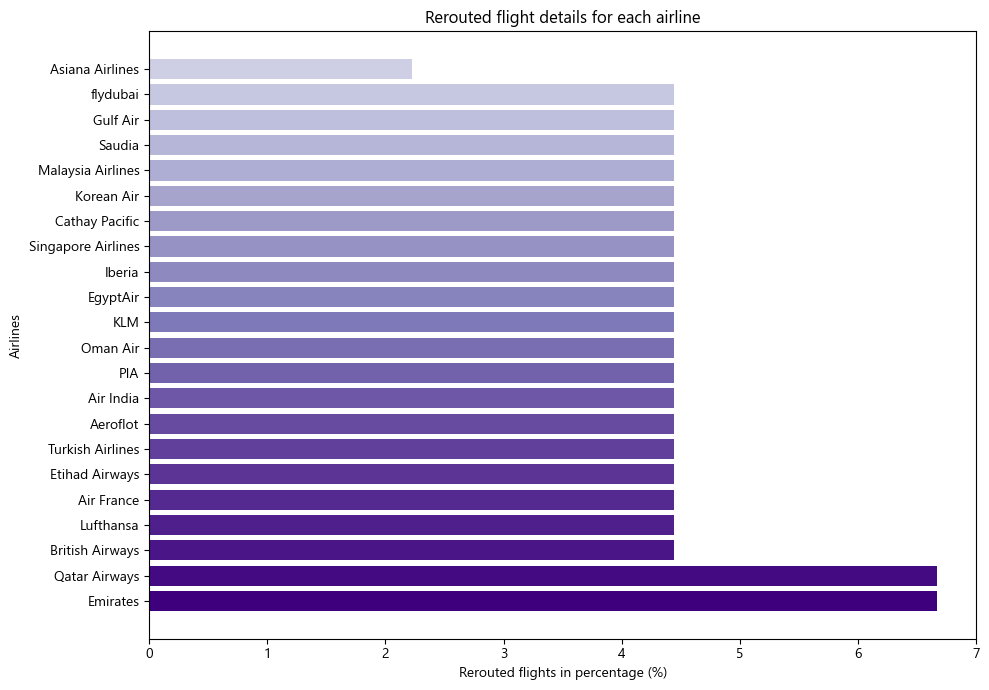

In [41]:
total_rerouted_flight = flight_rerouted["airline"].value_counts()
reroute_percentage = total_rerouted_flight / total_rerouted_flight.sum() * 100

plt.figure(figsize =(10,7))

plt.barh(total_rerouted_flight.index,reroute_percentage, color = plt.cm.Purples(np.linspace(1,0.3,len(total_rerouted_flight))))

plt.xlabel("Rerouted flights in percentage (%)")
plt.ylabel("Airlines")
plt.title("Rerouted flight details for each airline")
plt.tight_layout()
plt.show()

#### DATA ANALYSIS:
#### Airloss Analysis: 

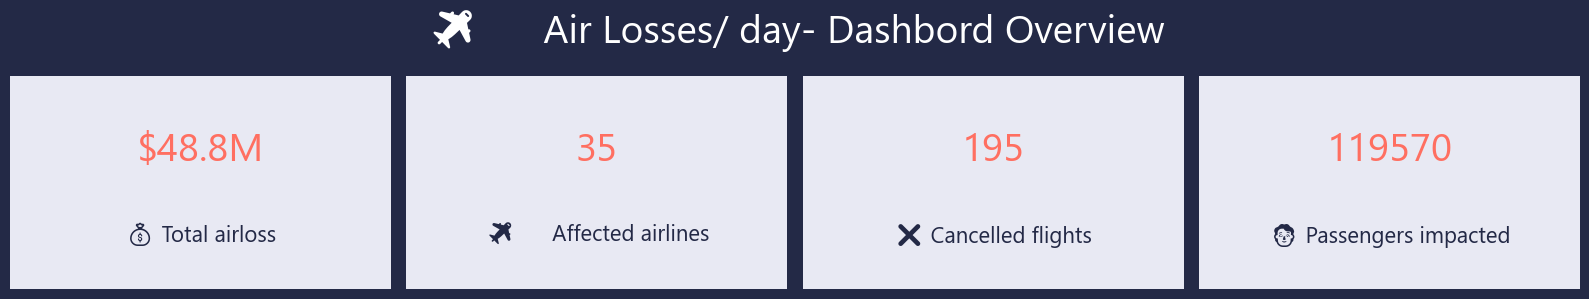

In [42]:
# cleaning the estimation loss data
airloss_estimation["estimated_daily_loss_usd"] = (airloss_estimation["estimated_daily_loss_usd"]
                                                  .astype(str)
                                                  .str.replace(",","")
                                                  .astype(float))

plt.rcParams["font.family"] = 'Segoe UI Emoji'

#preparing KPI values 

total_losses_millions = airloss_estimation["estimated_daily_loss_usd"].sum() /1e6 #covert to million
affected_airlines = airloss_estimation["airline"].nunique()
cancelled_flights = airloss_estimation["cancelled_flights"].sum()
passenger_impacted = airloss_estimation["passengers_impacted"].sum()

#creating KPI

kpi = [
    ('💰 Total airloss' , f'${total_losses_millions:.1f}M'),
    ('✈️ Affected airlines' , f'{affected_airlines}'),
    ('❌ Cancelled flights' , f'{cancelled_flights}'),
    ('🧑 Passengers impacted' , f'{passenger_impacted}')
]

# Attractive theme colors     
BG = '#232946'          # Deep blue
PANEL = '#E8E9F3'       # Soft light blue
LABEL_COLOR = '#232946' # Deep blue for labels
VALUE_COLOR = '#FF6F61' # Coral for value

fig,axes = plt.subplots(1,4,figsize=(16,3))
fig.patch.set_facecolor(BG)

for i,(ax,(label,value)) in enumerate(zip(axes,kpi)):
    ax.set_facecolor(PANEL)
    bbox =FancyBboxPatch(
        (0,0),1,1,
        boxstyle ="round,pad = 0.04",
        ec="none", fc=PANEL,
        transform = ax.transAxes , zorder = 0
    )
    ax.add_patch(bbox)

    for spine in ax.spines.values(): spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    ax.text(0.5,0.65,value,ha="center",va="center",
            fontsize=28,fontweight='bold',color=VALUE_COLOR,transform =ax.transAxes)
    ax.text(0.5,0.25,label,ha="center",va="center",
            fontsize=16,fontweight='bold',color=LABEL_COLOR,transform = ax.transAxes)
plt.suptitle("✈️ Air Losses/ day- Dashbord Overview",
                 fontsize=28,fontweight='bold',color="white")
plt.tight_layout()
plt.show()

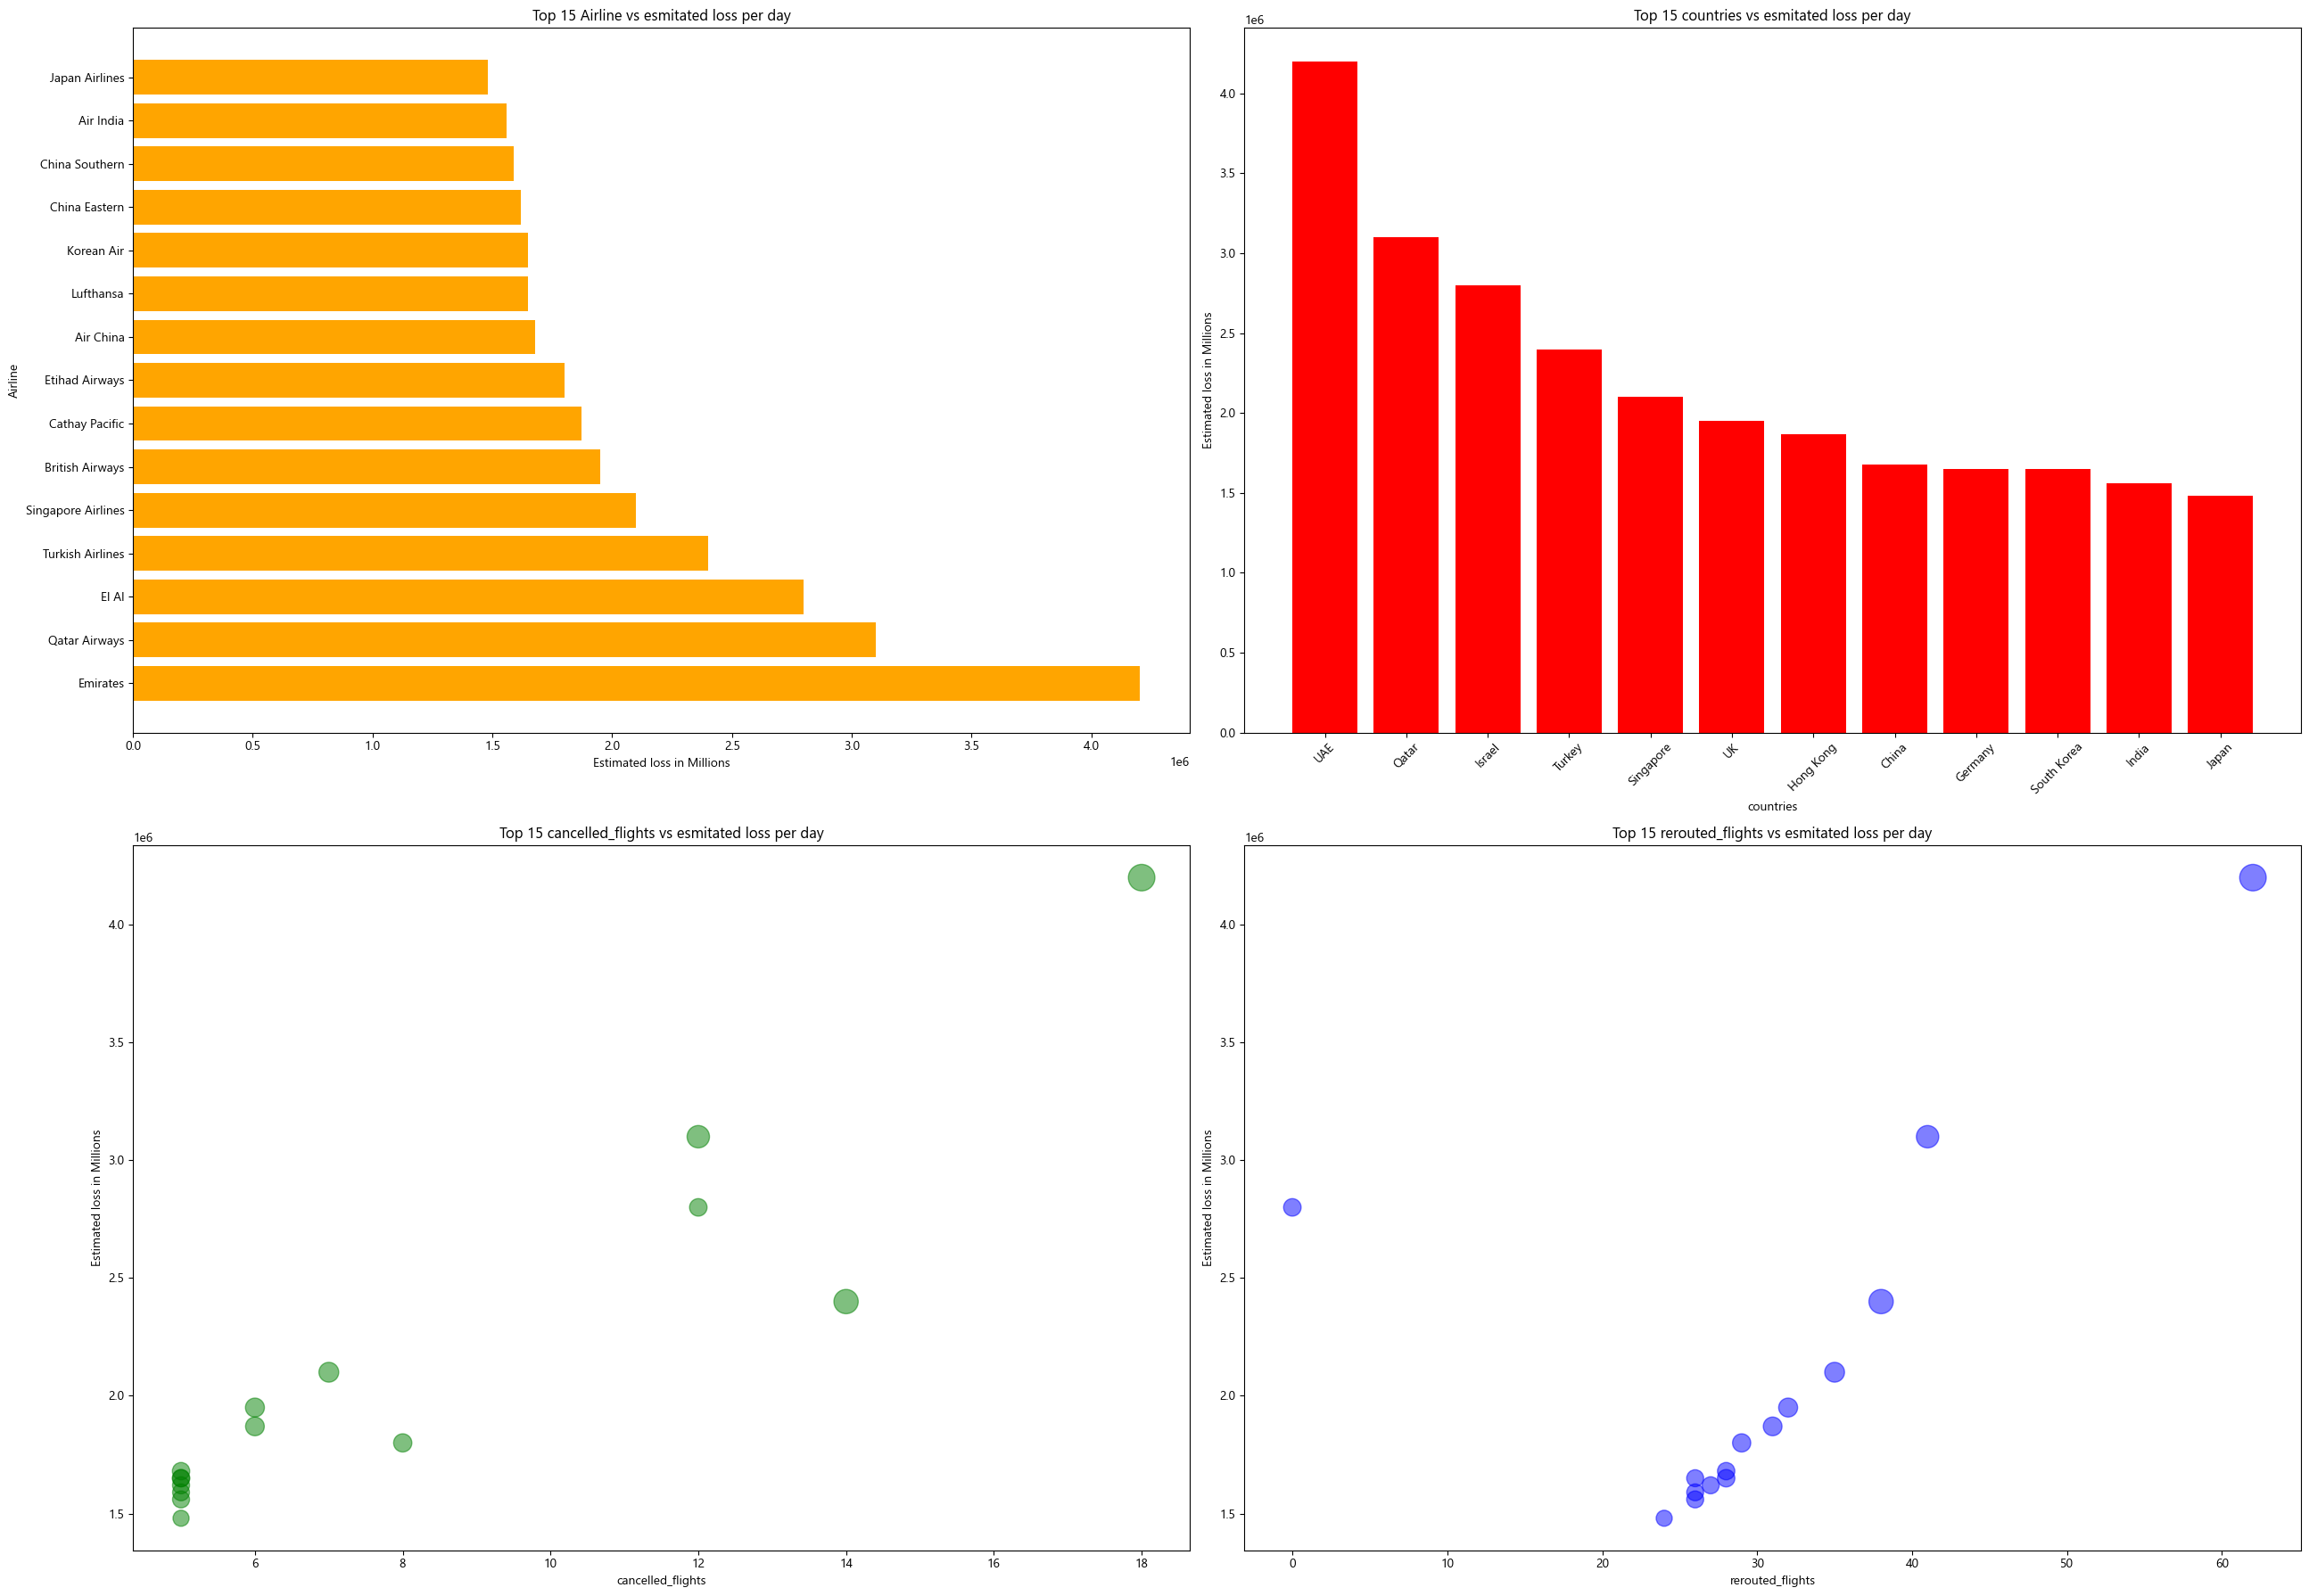

In [43]:
top15_estimation_loss = airloss_estimation.nlargest(15,"estimated_daily_loss_usd")

fig,axes = plt.subplots(2,2,figsize=(26,18))

axes[0,0].barh(top15_estimation_loss["airline"], top15_estimation_loss["estimated_daily_loss_usd"],color="orange")
axes[0,0].set_xlabel("Estimated loss in Millions")
axes[0,0].set_ylabel("Airline")
axes[0,0].set_title("Top 15 Airline vs esmitated loss per day")

axes[0,1].bar(top15_estimation_loss["country"],top15_estimation_loss["estimated_daily_loss_usd"],color="red")
axes[0,1].set_ylabel("Estimated loss in Millions")
axes[0,1].set_xlabel("countries")
axes[0,1].tick_params(axis='x',labelrotation = 45)
axes[0,1].set_title("Top 15 countries vs esmitated loss per day")


axes[1,0].scatter(top15_estimation_loss["cancelled_flights"], top15_estimation_loss["estimated_daily_loss_usd"],color="green", alpha = 0.5,
                  s = top15_estimation_loss["passengers_impacted"]/20)
axes[1,0].set_ylabel("Estimated loss in Millions")
axes[1,0].set_xlabel("cancelled_flights")
axes[1,0].set_title("Top 15 cancelled_flights vs esmitated loss per day")

axes[1,1].scatter(top15_estimation_loss["rerouted_flights"], top15_estimation_loss["estimated_daily_loss_usd"],color="blue", alpha = 0.5,
                  s = top15_estimation_loss["passengers_impacted"]/20)
axes[1,1].set_ylabel("Estimated loss in Millions")
axes[1,1].set_xlabel("rerouted_flights")
axes[1,1].set_title("Top 15 rerouted_flights vs esmitated loss per day")
plt.tight_layout()
plt.show()